**Lab Assignment - 4 : End-to-End Machine Learning Project: Airbnb Price Prediction**


**Task 1 - Data Analysis and Preparation**

In [1]:
# ============================================
# TASK 1: DATA ANALYSIS AND PREPARATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_regression

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


# Load Airbnb dataset
df = pd.read_csv("AB_NYC_2019.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

# Dataset information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nDataset Information:")
df.info()

# Statistical summary of numerical columns
display(df.describe().T)

# Statistical summary including categorical variables
display(df.describe(include="object").T)

# Calculate missing values
missing_data = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data.sort_values(
    by="Missing_Percentage",
    ascending=False
)

display(missing_data)

Dataset loaded successfully.
Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Dataset Shape: (48895, 16)

Column Names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data Types:


id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_revie

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


,count,unique,top,freq
name,48879,47905,Hillside Hotel,18
host_name,48874,11452,Michael,417
neighbourhood_group,48895,5,Manhattan,21661
neighbourhood,48895,221,Williamsburg,3920
room_type,48895,3,Entire home/apt,25409
last_review,38843,1764,2019-06-23,1413


,Missing_Count,Missing_Percentage
last_review,10052,20.558339
reviews_per_month,10052,20.558339
host_name,21,0.042949
name,16,0.032723
neighbourhood_group,0,0.000000
neighbourhood,0,0.000000
id,0,0.000000
host_id,0,0.000000
longitude,0,0.000000
latitude,0,0.000000


**Check Missing Values**

In [2]:
# Calculate missing values
missing_data = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data.sort_values(
    by="Missing_Percentage",
    ascending=False
)

display(missing_data)


# Check duplicate rows
duplicate_rows = df.duplicated().sum()

# Check duplicate listing IDs
duplicate_ids = df["id"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate listing IDs:", duplicate_ids)

,Missing_Count,Missing_Percentage
last_review,10052,20.558339
reviews_per_month,10052,20.558339
host_name,21,0.042949
name,16,0.032723
neighbourhood_group,0,0.000000
neighbourhood,0,0.000000
id,0,0.000000
host_id,0,0.000000
longitude,0,0.000000
latitude,0,0.000000


Duplicate rows: 0
Duplicate listing IDs: 0


**Check Invalid Values**

In [3]:
# Check important numerical variables for invalid values

print("Listings with price <= 0:",
      (df["price"] <= 0).sum())

print("Listings with minimum_nights <= 0:",
      (df["minimum_nights"] <= 0).sum())

print("Listings with reviews < 0:",
      (df["number_of_reviews"] < 0).sum())

print("Listings with availability outside 0-365:",
      ((df["availability_365"] < 0) |
       (df["availability_365"] > 365)).sum())

# Remove records with zero or negative Airbnb price
df = df[df["price"] > 0].copy()

print("Shape after removing invalid prices:", df.shape)

Listings with price <= 0: 11
Listings with minimum_nights <= 0: 0
Listings with reviews < 0: 0
Listings with availability outside 0-365: 0
Shape after removing invalid prices: (48884, 16)


**Exploratory Data Analysis**

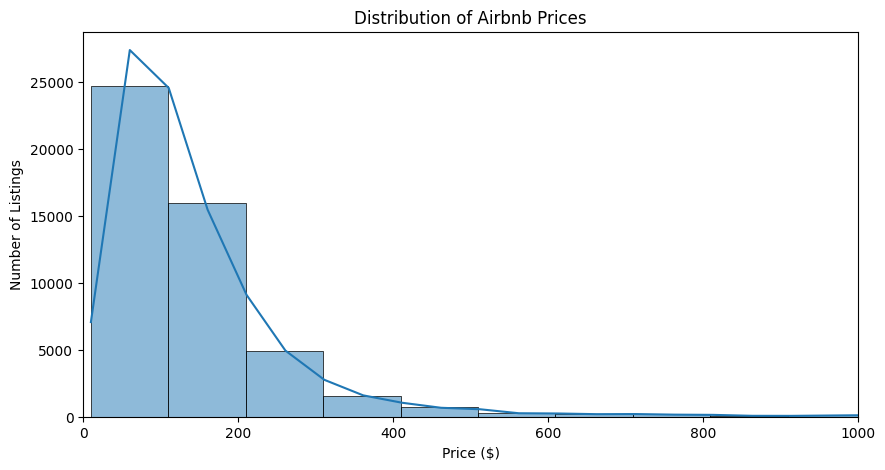

In [4]:
plt.figure(figsize=(10, 5))

sns.histplot(df["price"], bins=100, kde=True)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")
plt.xlim(0, 1000)

plt.show()

**Numerical Outlier Analysis**

,0.010,0.250,0.500,0.750,0.950,0.990,0.995,1.000
price,30.00,69.00,106.00,175.00,355.00,799.0000,1000.0000,10000.0
minimum_nights,1.00,1.00,3.00,5.00,30.00,45.0000,90.0000,1250.0
number_of_reviews,0.00,1.00,5.00,24.00,114.00,214.0000,256.5850,629.0
reviews_per_month,0.02,0.19,0.72,2.02,4.64,7.1968,8.4252,58.5
calculated_host_listings_count,1.00,1.00,1.00,2.00,15.00,232.0000,327.0000,327.0
availability_365,0.00,0.00,45.00,227.00,359.00,365.0000,365.0000,365.0


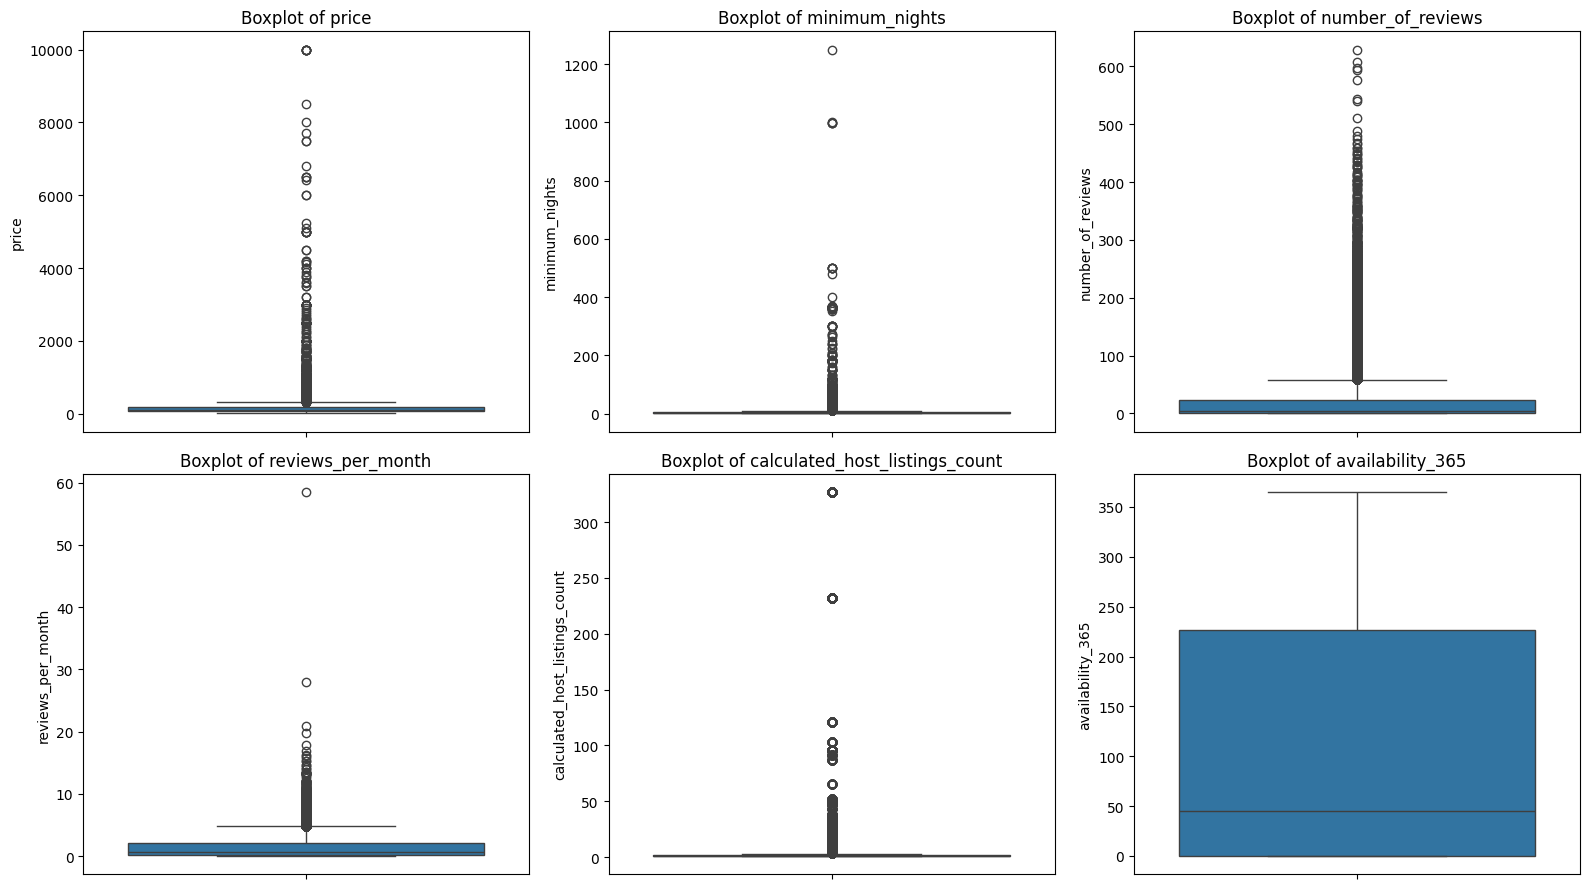

In [5]:
numerical_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

# Display selected percentiles
percentiles = df[numerical_columns].quantile(
    [0.01, 0.25, 0.50, 0.75, 0.95, 0.99, 0.995, 1.00]
)

display(percentiles.T)

## visualization of outliers in the numerical columns

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, column in zip(axes.flatten(), numerical_columns):
    sns.boxplot(y=df[column], ax=ax)
    ax.set_title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

**Feature Engineering**

In [6]:
# Convert last_review to datetime
df["last_review"] = pd.to_datetime(
    df["last_review"],
    errors="coerce"
)

print(df["last_review"].dtype)

datetime64[ns]


**Create Date-Based Features**

In [7]:
# Create review date features

df["last_review_year"] = df["last_review"].dt.year
df["last_review_month"] = df["last_review"].dt.month

# Whether the listing has received at least one review
df["has_review"] = df["number_of_reviews"].gt(0).astype(int)

# Whether review date is available
df["has_last_review"] = df["last_review"].notna().astype(int)

# Display new features
display(
    df[
        [
            "last_review",
            "last_review_year",
            "last_review_month",
            "number_of_reviews",
            "has_review",
            "has_last_review"
        ]
    ].head()
)

,last_review,last_review_year,last_review_month,number_of_reviews,has_review,has_last_review
0,2018-10-19,2018.0,10.0,9,1,1
1,2019-05-21,2019.0,5.0,45,1,1
2,NaT,NaN,NaN,0,0,0
3,2019-07-05,2019.0,7.0,270,1,1
4,2018-11-19,2018.0,11.0,9,1,1


**Handle Missing reviews_per_month**

In [8]:
# Missing reviews_per_month is treated as zero review activity
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

print(
    "Missing reviews_per_month after imputation:",
    df["reviews_per_month"].isnull().sum()
)

Missing reviews_per_month after imputation: 0


**Geographic Feature Engineering**

In [9]:
# Approximate NYC central location
nyc_lat = 40.7128
nyc_lon = -74.0060

# Approximate Euclidean geographic distance
df["distance_from_nyc_center"] = np.sqrt(
    (df["latitude"] - nyc_lat) ** 2 +
    (df["longitude"] - nyc_lon) ** 2
)

display(
    df[
        [
            "latitude",
            "longitude",
            "distance_from_nyc_center"
        ]
    ].head()
)

,latitude,longitude,distance_from_nyc_center
0,40.64749,-73.97237,0.073460
1,40.75362,-73.98377,0.046481
2,40.80902,-73.94190,0.115616
3,40.68514,-73.95976,0.053881
4,40.79851,-73.94399,0.105790


**Price by Neighbourhood Group**

,count,mean,median
neighbourhood_group,,,
Manhattan,21660,196.884903,150.0
Brooklyn,20095,124.438915,90.0
Queens,5666,99.517649,75.0
Staten Island,373,114.812332,75.0
Bronx,1090,87.577064,65.0


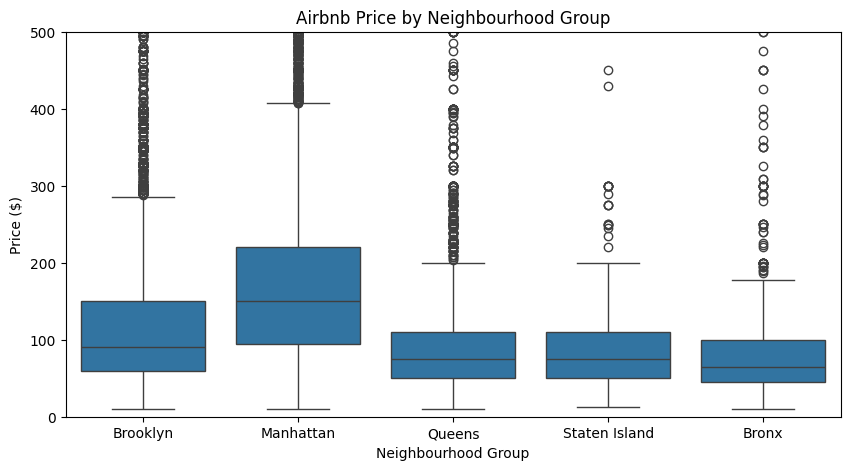

In [10]:
neighbourhood_price = (
    df.groupby("neighbourhood_group")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

display(neighbourhood_price)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="neighbourhood_group",
    y="price"
)

plt.title("Airbnb Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price ($)")
plt.ylim(0, 500)

plt.show()

**Price by Room Type**

,count,mean,median
room_type,,,
Entire home/apt,25407,211.810918,160.0
Private room,22319,89.809131,70.0
Shared room,1158,70.248705,45.0


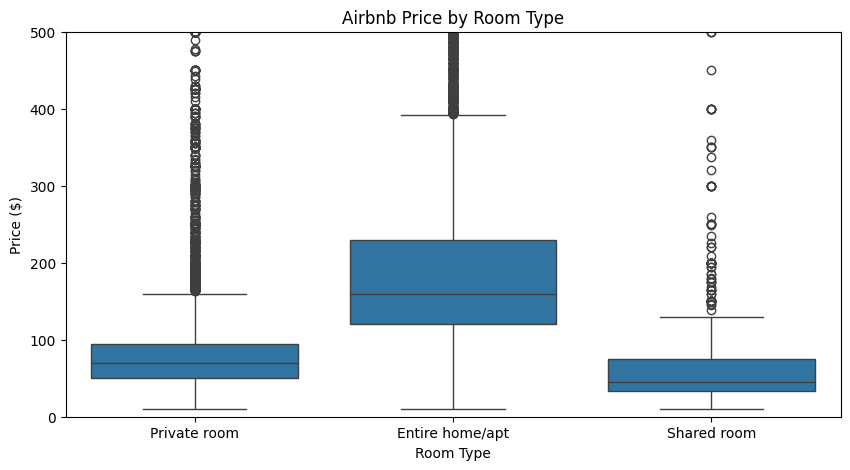

In [11]:
room_price = (
    df.groupby("room_type")["price"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
)

display(room_price)

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="room_type",
    y="price"
)

plt.title("Airbnb Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price ($)")
plt.ylim(0, 500)

plt.show()

**Correlation Analysis**

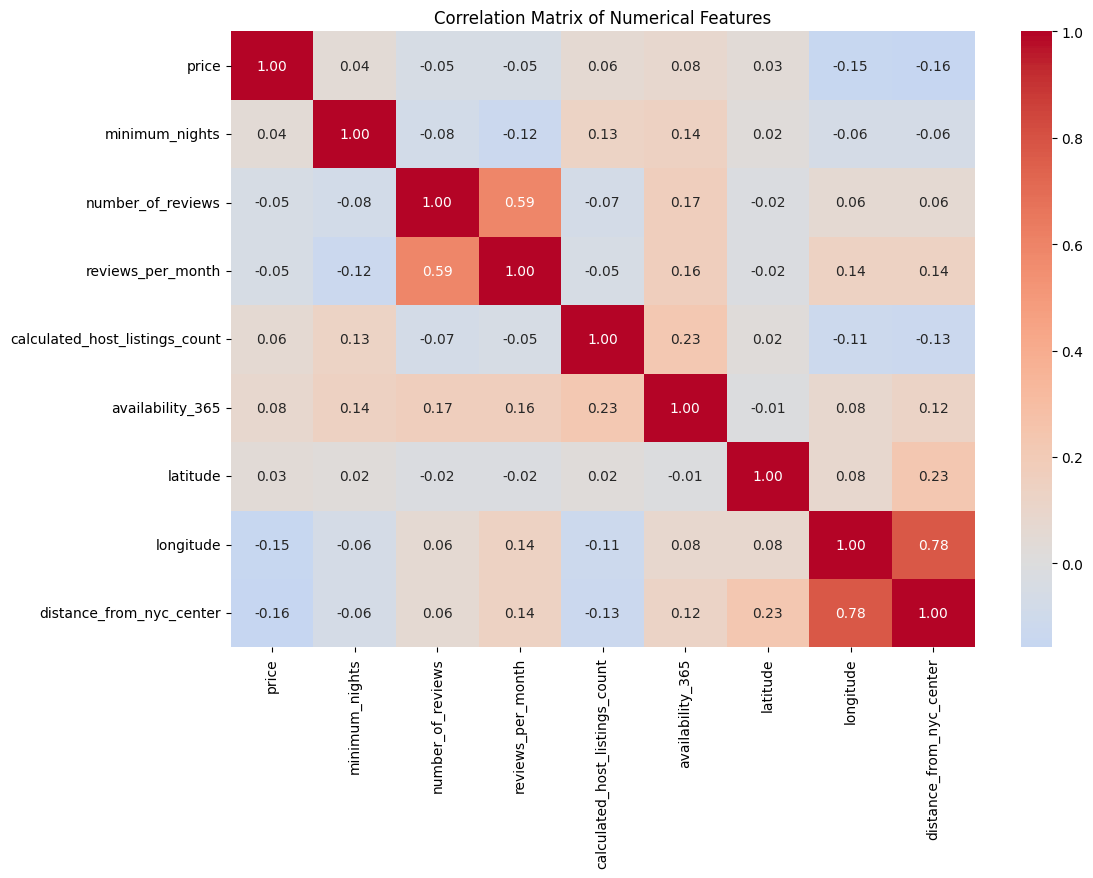

In [12]:
correlation_columns = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "latitude",
    "longitude",
    "distance_from_nyc_center"
]

corr_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

**Outlier Treatment**

In [13]:
# Examine extreme price values
print("99th percentile of price:",
      df["price"].quantile(0.99))

print("99.5th percentile of price:",
      df["price"].quantile(0.995))

print("Maximum price:",
      df["price"].max())

99th percentile of price: 799.0
99.5th percentile of price: 1000.0
Maximum price: 10000


**Remove Extreme Price Outliers**

In [14]:
price_upper_limit = df["price"].quantile(0.995)

print("Price outlier threshold:", price_upper_limit)

before = len(df)

df = df[df["price"] <= price_upper_limit].copy()

after = len(df)

print("Rows before outlier treatment:", before)
print("Rows after outlier treatment:", after)
print("Rows removed:", before - after)

Price outlier threshold: 1000.0
Rows before outlier treatment: 48884
Rows after outlier treatment: 48645
Rows removed: 239


**Handle Extreme Minimum-Night Values**

In [15]:
minimum_nights_upper = df["minimum_nights"].quantile(0.99)

print("99th percentile of minimum_nights:",
      minimum_nights_upper)

df["minimum_nights_capped"] = df["minimum_nights"].clip(
    upper=minimum_nights_upper
)

print(
    "Maximum after capping:",
    df["minimum_nights_capped"].max()
)

99th percentile of minimum_nights: 40.0
Maximum after capping: 40


**Log Transform the Target**

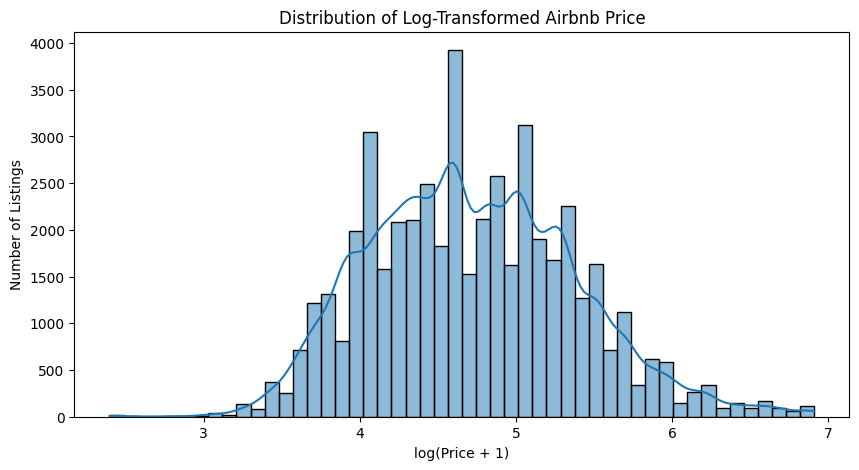

In [16]:
# Log transformation of target variable
df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(10, 5))

sns.histplot(
    df["log_price"],
    bins=50,
    kde=True
)

plt.title("Distribution of Log-Transformed Airbnb Price")
plt.xlabel("log(Price + 1)")
plt.ylabel("Number of Listings")

plt.show()

**Feature Selection**

In [17]:
# Target variable
target = "log_price"

# Features selected for modeling
feature_columns = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "minimum_nights_capped",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "last_review_year",
    "last_review_month",
    "has_review",
    "has_last_review",
    "distance_from_nyc_center"
]

X = df[feature_columns].copy()
y = df[target].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

display(X.head())

Feature matrix shape: (48645, 15)
Target shape: (48645,)


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights_capped,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,last_review_year,last_review_month,has_review,has_last_review,distance_from_nyc_center
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,1,9,0.21,6,365,2018.0,10.0,1,1,0.073460
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,1,45,0.38,2,355,2019.0,5.0,1,1,0.046481
2,Manhattan,Harlem,40.80902,-73.94190,Private room,3,0,0.00,1,365,NaN,NaN,0,0,0.115616
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,1,270,4.64,1,194,2019.0,7.0,1,1,0.053881
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,10,9,0.10,1,0,2018.0,11.0,1,1,0.105790


**Separate Numerical and Categorical Features**

In [18]:
categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights_capped",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "last_review_year",
    "last_review_month",
    "has_review",
    "has_last_review",
    "distance_from_nyc_center"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['neighbourhood_group', 'neighbourhood', 'room_type']

Numerical features:
['latitude', 'longitude', 'minimum_nights_capped', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'last_review_year', 'last_review_month', 'has_review', 'has_last_review', 'distance_from_nyc_center']


**Task 2 - Model Training and Evaluation**

In [20]:
# ============================================
# TASK 2: MODEL TRAINING AND EVALUATION
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.pipeline import Pipeline

import joblib

import warnings
warnings.filterwarnings("ignore")

In [24]:
# Features and target from Task 1

X = df[feature_columns].copy()

# Target is log-transformed price
y = df["log_price"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

X shape: (48645, 15)
y shape: (48645,)
Training samples: 38916
Testing samples: 9729


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights_capped",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "last_review_year",
    "last_review_month",
    "has_review",
    "has_last_review",
    "distance_from_nyc_center"
]

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Complete preprocessing
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


**Creating Model Pipelines**

In [26]:
# ============================================
# MODEL 1: LINEAR REGRESSION
# ============================================

linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])


# ============================================
# MODEL 2: RANDOM FOREST
# ============================================

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ))
])


# ============================================
# MODEL 3: GRADIENT BOOSTING
# ============================================

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


# ============================================
# MODEL 4: HISTOGRAM GRADIENT BOOSTING
# ============================================

hist_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(
        max_iter=150,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    ))
])



**Train the Models**

In [27]:
models = {
    "Linear Regression": linear_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "HistGradient Boosting": hist_pipeline
}

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} completed.")

print("\nAll models trained successfully.")

Training Linear Regression...
Linear Regression completed.
Training Random Forest...
Random Forest completed.
Training Gradient Boosting...
Gradient Boosting completed.
Training HistGradient Boosting...


  File "c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                   

HistGradient Boosting completed.

All models trained successfully.


**Create Evaluation Function**

In [28]:
def evaluate_model(model, X_data, y_data):
    """
    Evaluate a regression model using
    MAE, RMSE and R2.
    """

    predictions = model.predict(X_data)

    mae = mean_absolute_error(y_data, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_data, predictions)
    )

    r2 = r2_score(y_data, predictions)

    return mae, rmse, r2

**Compare Models**

In [29]:
results = []

for name, model in trained_models.items():

    train_mae, train_rmse, train_r2 = evaluate_model(
        model,
        X_train,
        y_train
    )

    test_mae, test_rmse, test_r2 = evaluate_model(
        model,
        X_test,
        y_test
    )

    results.append({
        "Model": name,

        "Train MAE": train_mae,
        "Test MAE": test_mae,

        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,

        "Train R2": train_r2,
        "Test R2": test_r2
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        by="Test R2",
        ascending=False
    )
)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
3,HistGradient Boosting,0.289637,0.298392,0.388318,0.398480,0.654329,0.643597
1,Random Forest,0.109924,0.294855,0.150655,0.398575,0.947969,0.643428
2,Gradient Boosting,0.307131,0.310442,0.411581,0.413748,0.611672,0.615763
0,Linear Regression,0.316520,0.318462,0.423042,0.424371,0.589743,0.595779


**Visualize Model Comparison**

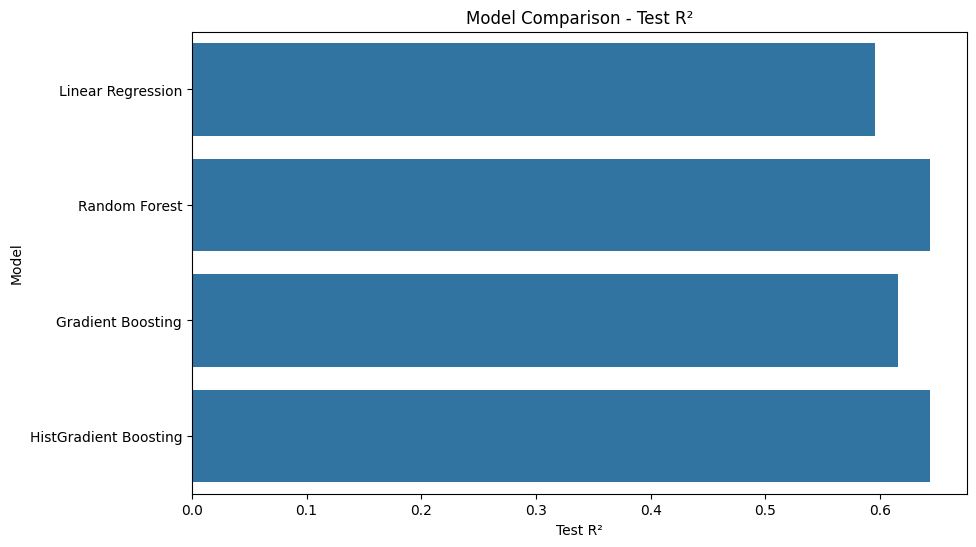

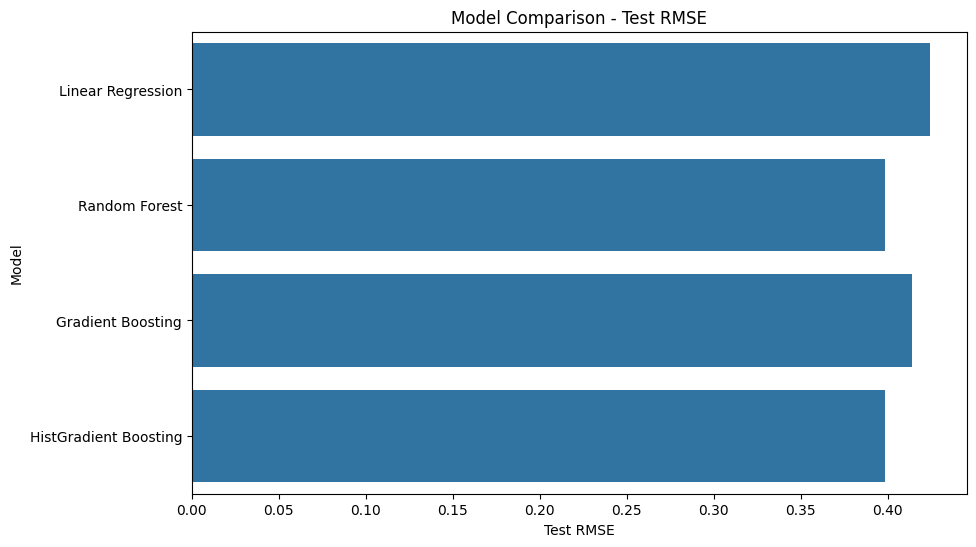

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Test R2",
    y="Model"
)

plt.title("Model Comparison - Test R²")
plt.xlabel("Test R²")
plt.ylabel("Model")

plt.show()


## comparing rmse of the models
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Test RMSE",
    y="Model"
)

plt.title("Model Comparison - Test RMSE")
plt.xlabel("Test RMSE")
plt.ylabel("Model")

plt.show()

**Select the Best Model**

In [31]:
best_model_name = results_df.loc[
    results_df["Test R2"].idxmax(),
    "Model"
]

print("Best model based on Test R²:")
print(best_model_name)

Best model based on Test R²:
HistGradient Boosting


**Convert Predictions Back to Actual Price**

In [32]:
# Select best model
best_model = trained_models[best_model_name]

# Predictions in log-price space
y_pred_log = best_model.predict(X_test)

# Convert back to original dollar price
y_pred_price = np.expm1(y_pred_log)

# Actual prices
y_test_price = np.expm1(y_test)

print("First 10 actual prices:")
print(y_test_price.head(10).values)

print("\nFirst 10 predicted prices:")
print(y_pred_price[:10])

First 10 actual prices:
[ 99. 225. 268.  47. 250. 110. 100. 180. 160. 423.]

First 10 predicted prices:
[134.21622737 268.94112901 207.44170367  61.06105365 112.76519145
 149.78979388 140.4061621  134.26616305 163.50947494 280.72367506]


**Evaluate in Dollar Values**

In [33]:
mae_price = mean_absolute_error(
    y_test_price,
    y_pred_price
)

rmse_price = np.sqrt(
    mean_squared_error(
        y_test_price,
        y_pred_price
    )
)

r2_price = r2_score(
    y_test_price,
    y_pred_price
)

print("Final Test Performance")
print("----------------------")
print(f"MAE  : ${mae_price:.2f}")
print(f"RMSE : ${rmse_price:.2f}")
print(f"R²   : {r2_price:.4f}")

Final Test Performance
----------------------
MAE  : $45.96
RMSE : $88.93
R²   : 0.4332


**Random Forest Hyperparameter Tuning**

In [34]:
# Random Forest pipeline for tuning

rf_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

rf_param_grid = {
    "model__n_estimators": [
        100,
        200,
        300
    ],

    "model__max_depth": [
        None,
        10,
        20,
        30
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__max_features": [
        "sqrt",
        "log2",
        0.7
    ]
}

print("Hyperparameter search space created.")

Hyperparameter search space created.


**Randomized Search on RF**

In [35]:
rf_random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(
    X_train,
    y_train
)

print("Best Hyperparameters:")
print(rf_random_search.best_params_)

print("\nBest CV RMSE:")
print(
    -rf_random_search.best_score_
)

tuned_model = rf_random_search.best_estimator_

print("Tuned model created successfully.")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Hyperparameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.7, 'model__max_depth': 20}

Best CV RMSE:
0.4042465539429136
Tuned model created successfully.


**Evaluate Tuned Model**

In [36]:
train_predictions = tuned_model.predict(X_train)
test_predictions = tuned_model.predict(X_test)

train_r2 = r2_score(
    y_train,
    train_predictions
)

test_r2 = r2_score(
    y_test,
    test_predictions
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_predictions
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

print("Tuned Model Performance")
print("-----------------------")

print(f"Train R²   : {train_r2:.4f}")
print(f"Test R²    : {test_r2:.4f}")

print(f"\nTrain RMSE : {train_rmse:.4f}")
print(f"Test RMSE  : {test_rmse:.4f}")

print(
    f"\nR² Gap     : {train_r2 - test_r2:.4f}"
)

Tuned Model Performance
-----------------------
Train R²   : 0.8789
Test R²    : 0.6521

Train RMSE : 0.2298
Test RMSE  : 0.3937

R² Gap     : 0.2268


**Automatically Check Overfitting**

In [37]:
r2_gap = train_r2 - test_r2

print("Overfitting Analysis")
print("--------------------")

if r2_gap > 0.15:
    print("⚠️ Possible overfitting detected.")
    print("The training R² is considerably higher than the testing R².")

elif r2_gap < 0.05:
    print("✅ No significant overfitting detected.")
    print("Training and testing performance are relatively close.")

else:
    print("⚠️ Mild overfitting may be present.")
    print("The performance gap should be monitored.")

Overfitting Analysis
--------------------
⚠️ Possible overfitting detected.
The training R² is considerably higher than the testing R².


**Final Predictions & Regression Metrics**

In [38]:
# Final model predictions in log-space

final_pred_log = tuned_model.predict(X_test)

# Convert back to original price
final_pred_price = np.expm1(final_pred_log)

actual_price = np.expm1(y_test)

final_mae = mean_absolute_error(
    actual_price,
    final_pred_price
)

final_rmse = np.sqrt(
    mean_squared_error(
        actual_price,
        final_pred_price
    )
)

final_r2 = r2_score(
    actual_price,
    final_pred_price
)

print("====================================")
print("FINAL MODEL PERFORMANCE")
print("====================================")

print(f"MAE  : ${final_mae:.2f}")
print(f"RMSE : ${final_rmse:.2f}")
print(f"R²   : {final_r2:.4f}")

FINAL MODEL PERFORMANCE
MAE  : $45.02
RMSE : $87.28
R²   : 0.4541


**Prediction Visualization**

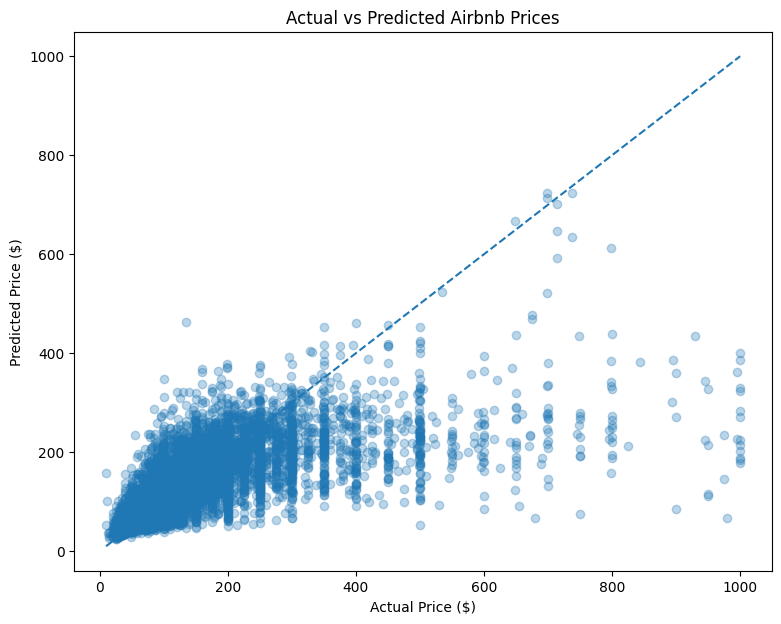

In [39]:
plt.figure(figsize=(9, 7))

plt.scatter(
    actual_price,
    final_pred_price,
    alpha=0.3
)

# Perfect prediction line
min_value = min(
    actual_price.min(),
    final_pred_price.min()
)

max_value = max(
    actual_price.max(),
    final_pred_price.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Airbnb Prices")

plt.show()

**Residual Analysis**

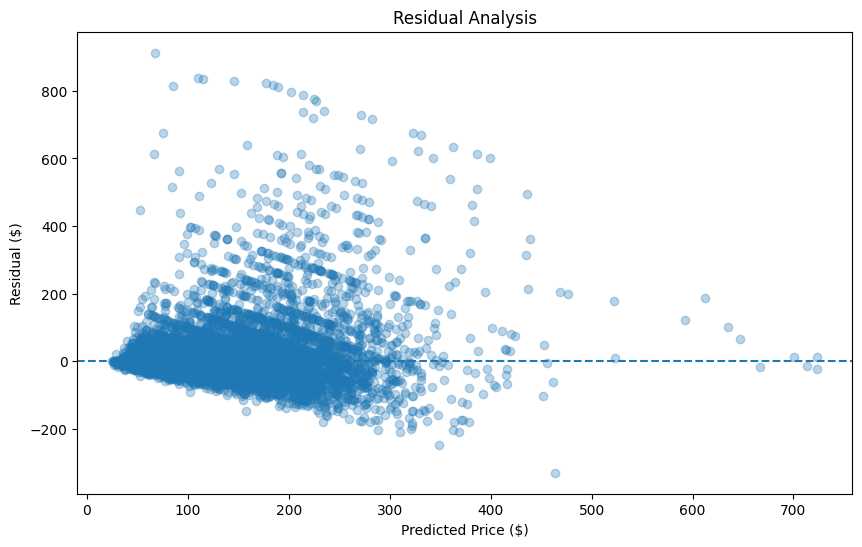

In [40]:
residuals = actual_price - final_pred_price

plt.figure(figsize=(10, 6))

plt.scatter(
    final_pred_price,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual ($)")
plt.title("Residual Analysis")

plt.show()

**Save Final Pipeline**

In [41]:
# Save the complete preprocessing + model pipeline

MODEL_PATH = "airbnb_price_prediction_pipeline.pkl"

joblib.dump(
    tuned_model,
    MODEL_PATH
)

print(
    f"Final pipeline saved successfully as: {MODEL_PATH}"
)

Final pipeline saved successfully as: airbnb_price_prediction_pipeline.pkl


**Loading and testing saved Model**


In [42]:
# Load saved pipeline

loaded_model = joblib.load(
    "airbnb_price_prediction_pipeline.pkl"
)

print("Pipeline loaded successfully.")

# Predict using the loaded pipeline

test_sample = X_test.iloc[:5]

predicted_log_price = loaded_model.predict(
    test_sample
)

predicted_price = np.expm1(
    predicted_log_price
)

display(
    pd.DataFrame({
        "Actual Price": np.expm1(
            y_test.iloc[:5]
        ).values,
        "Predicted Price": predicted_price
    })
)

Pipeline loaded successfully.


,Actual Price,Predicted Price
0,99.0,163.734274
1,225.0,248.041629
2,268.0,239.672244
3,47.0,62.753253
4,250.0,123.692757


**Complete HistGradient Boosting Pipeline**

In [43]:
# ============================================
# HISTOGRAM GRADIENT BOOSTING TUNING
# ============================================

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

# Create a fresh preprocessing pipeline + model
hist_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(
        random_state=42
    ))
])

print("HistGradient Boosting tuning pipeline created.")

# Hyperparameter search space for
# HistGradientBoostingRegressor

hist_param_grid = {
    "model__max_iter": [
        100,
        200,
        300,
        500
    ],

    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.10
    ],

    "model__max_leaf_nodes": [
        15,
        31,
        63
    ],

    "model__max_depth": [
        None,
        5,
        10,
        15
    ],

    "model__min_samples_leaf": [
        10,
        20,
        30,
        50
    ],

    "model__l2_regularization": [
        0,
        0.1,
        1,
        10
    ]
}

print("Hyperparameter search space created.")




HistGradient Boosting tuning pipeline created.
Hyperparameter search space created.


In [44]:
hist_random_search = RandomizedSearchCV(
    estimator=hist_tuning_pipeline,
    param_distributions=hist_param_grid,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter tuning...")

hist_random_search.fit(
    X_train,
    y_train
)

print("Hyperparameter tuning completed.")


Starting hyperparameter tuning...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Hyperparameter tuning completed.


In [45]:
print("====================================")
print("BEST HISTGRADIENT BOOSTING PARAMETERS")
print("====================================")

print(hist_random_search.best_params_)


BEST HISTGRADIENT BOOSTING PARAMETERS
{'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 63, 'model__max_iter': 200, 'model__max_depth': 15, 'model__learning_rate': 0.05, 'model__l2_regularization': 10}


In [46]:
best_cv_rmse = -hist_random_search.best_score_

print(
    f"Best Cross-Validation RMSE: {best_cv_rmse:.4f}"
)

Best Cross-Validation RMSE: 0.4022


In [47]:
tuned_hist_model = hist_random_search.best_estimator_

print("Tuned HistGradient Boosting model created successfully.")

Tuned HistGradient Boosting model created successfully.


In [48]:
# Predictions
train_pred_log = tuned_hist_model.predict(X_train)
test_pred_log = tuned_hist_model.predict(X_test)

# Training metrics
train_mae = mean_absolute_error(
    y_train,
    train_pred_log
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_pred_log
    )
)

train_r2 = r2_score(
    y_train,
    train_pred_log
)

# Testing metrics
test_mae = mean_absolute_error(
    y_test,
    test_pred_log
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred_log
    )
)

test_r2 = r2_score(
    y_test,
    test_pred_log
)

print("====================================")
print("TUNED HISTGRADIENT BOOSTING")
print("====================================")

print("\nTraining Performance")
print(f"MAE  : {train_mae:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")

print("\nTesting Performance")
print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

TUNED HISTGRADIENT BOOSTING

Training Performance
MAE  : 0.2750
RMSE : 0.3698
R²   : 0.6864

Testing Performance
MAE  : 0.2939
RMSE : 0.3939
R²   : 0.6518


In [49]:
r2_gap = train_r2 - test_r2

print("====================================")
print("OVERFITTING ANALYSIS")
print("====================================")

print(f"Train R² : {train_r2:.4f}")
print(f"Test R²  : {test_r2:.4f}")
print(f"R² Gap   : {r2_gap:.4f}")

if r2_gap > 0.15:
    print("\n⚠️ Possible overfitting detected.")
    print("The model performs substantially better on training data.")

elif r2_gap > 0.05:
    print("\n⚠️ Mild overfitting may be present.")
    print("There is a moderate difference between training and test performance.")

else:
    print("\n✅ No significant overfitting detected.")
    print("Training and testing performance are reasonably close.")

OVERFITTING ANALYSIS
Train R² : 0.6864
Test R²  : 0.6518
R² Gap   : 0.0346

✅ No significant overfitting detected.
Training and testing performance are reasonably close.


In [50]:
# Convert predictions back to original price scale

final_pred_price = np.expm1(test_pred_log)

actual_price = np.expm1(y_test)

In [51]:
final_mae = mean_absolute_error(
    actual_price,
    final_pred_price
)

final_rmse = np.sqrt(
    mean_squared_error(
        actual_price,
        final_pred_price
    )
)

final_r2 = r2_score(
    actual_price,
    final_pred_price
)

print("====================================")
print("FINAL HISTGRADIENT BOOSTING RESULTS")
print("====================================")

print(f"MAE  : ${final_mae:.2f}")
print(f"RMSE : ${final_rmse:.2f}")
print(f"R²   : {final_r2:.4f}")

FINAL HISTGRADIENT BOOSTING RESULTS
MAE  : $45.38
RMSE : $88.03
R²   : 0.4446


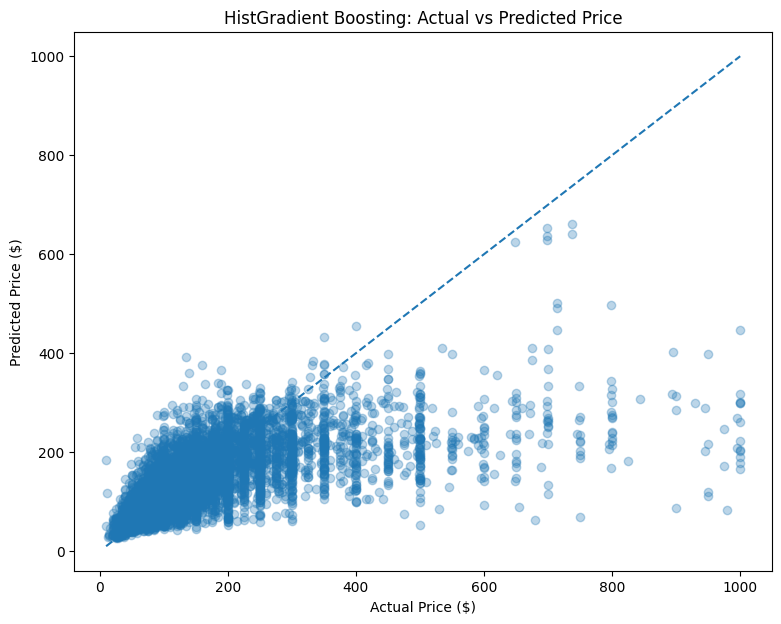

In [52]:
plt.figure(figsize=(9, 7))

plt.scatter(
    actual_price,
    final_pred_price,
    alpha=0.3
)

min_value = min(
    actual_price.min(),
    final_pred_price.min()
)

max_value = max(
    actual_price.max(),
    final_pred_price.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("HistGradient Boosting: Actual vs Predicted Price")

plt.show()

In [54]:
residuals = actual_price - final_pred_price

plt.figure(figsize=(10, 6))

plt.scatter(
    final_pred_price,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual ($)")# Load the saved pipeline
loaded_model = joblib.load(
    "airbnb_price_prediction_pipeline.pkl"
)

print("Saved pipeline loaded successfully.")

# Test prediction
sample_prediction_log = loaded_model.predict(
    X_test.iloc[:5]
)

sample_prediction_price = np.expm1(
    sample_prediction_log
)

display(
    pd.DataFrame({
        "Actual Price": np.expm1(
            y_test.iloc[:5]
        ).values,
        "Predicted Price": sample_prediction_price
    })
))
plt.title("HistGradient Boosting Residual Analysis")

plt.show()

SyntaxError: unmatched ')' (863085452.py, line 40)

In [55]:
import joblib

MODEL_PATH = "airbnb_price_prediction_pipeline.pkl"

joblib.dump(
    tuned_hist_model,
    MODEL_PATH
)

print("====================================")
print("MODEL SAVED")
print("====================================")
print(f"Saved as: {MODEL_PATH}")

MODEL SAVED
Saved as: airbnb_price_prediction_pipeline.pkl
